# Practical 4: Soil moisture data-assimilation within the FLEX model
[Lucas Boeykens](mailto:lucas.boeykens@kuleuven.be), [Elise Huysman](mailto:elyse.huysman@kuleuven.be) - 2026-12-18

## The principles of data assimilation
With data assimilation, we aim to improve the outcomes of a (hydrological) model by incorporating observations. Different types of observations can be used, but within hydrology it is common to use observations related to (one of) the state variables of the model. As such, data-assimilation tries to correct (update) the states of the hydrological with real observations, dependent on the uncertainties of both the model and the observations. By adjusting the model states, data-assimilation aims to improve the model results.

A wide range of data assimilation techniques exist, and can be divided into two main groups. The first one, the smoothing techniques, use both past, present and future observations to re-evaluate the model's states, but require more computing power. Filters, on the other hand, use only past and present observations to adjust the model states and thus operate in a real-time (using present observations) or in a step-by-step (using past observations) processing. 

Within the field of hydrology, soil moisture is commonly used type of observation. These observations can be derived from in situ measurements, but more often satellite products are used. Today, you will use one such product, the Soil Moisture Active Passive (SMAP) dataset, to update the soil reservoir ($S$) of the FLEX model (see practical 3) using a filtering technique, namely the Ensemble Kalman Filter.

## Ensemble Kalman Filter in the context of the FLEX model
Assume we have a state variable $x$, which could be, in our case, $S$; namely the volume of water in the soil reservoir of the FLEX model. This state variable at time $t+1$ will change as a function of the inputs and the parameters as follows:
$$
x_{t+1} = f_{t, t+1}(\bm{\alpha}, x_t, u_{t+1}) \tag{1}
$$

with $\bm{\alpha}$ being the vector of the model parameters, $u_{t+1}$ the inputs for the model at time $t+1$ and $x_t$ the state variable. Referring to the FLEX model, this would result in $\bm{\alpha}$ being the calibrated parameter vector $[\bm{X_1}, \bm{X_2},...,\bm{X_{10}}]$, $u_{t+1}$ being the inputs ($P$ and $E$) at time $t+1$ and $x_t$ being $S(t)$ ($S_t$). The state variable (the so-called a priori estimate or $x^-_{t+1}$) will then be updated (to the so-called a posteriori estimate $x^+_{t+1}$) based on the difference between the state variable and an observation of this state variable(e.g. measured soil moisture), taking into account the uncertainty of both the state variable and the
observation.

The ensemble part of the EnKF will allow us to get an uncertainty of the state variable $S$. Therefore, assume we have calibrated the FLEX model. With the calibrated model, multiple model runs are performed using disturbed (als named perturbed) model inputs ($P$ and $E$), which represent the noise (random error) on our inputs. To generate the perturbed inputs, we will multiply the orignal values (so called multiplicative perturbation) $J$ times with a random value (random for each model run and within one run for each day) with a factor drawn from a lognormal distribution. This will results in $J$ different values for $x_{t+1}$ ($x^-_{j, t+1}$ with $j \in J$ in the syllabus), from which we can estimate the variance ($\sigma^2_x$). The latter thus represents the uncertainty of our a priori state variable (i.e. the volume of water in the soil moisture reservoir).

With an estimate of $\sigma^2_x$, and knowledge of the observation uncertainty ($\sigma^2_y$; often a fixed value computed as the variance of the observations), we can update each of the J a priori state variables. The difference between the observation $y$ and $X^-_{t+1}$ (called the innovation) is added to the a priori estimates, multiplied with the Kalman gain ($K$). The latter hereby is a function of the uncertainty of both the observations and state variable and will determine how much the state variabble is updated. As such, the state variables are updated as follows:

$$
\begin{equation}
\begin{split}
x^+_{j,t+1} &= x^-_{j,t+1}+ K_{i+1} (y_{t+1} − x^-_{j,t+1}) \\
x^+_{j,t+1} &= x^-_{j,t+1}+ \frac{\sigma^2_x}{\sigma^2_x + \sigma^2_y} (y_{t+1} − x^-_{j,t+1})
\end{split}
\tag{2}
\end{equation}
$$

In [ ]:
# --- import modules ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, rootutils
from pathlib import Path

ROOT_PATH = rootutils.find_root(search_from=Path.cwd(), indicator=["environment.yml", "Data", "Scripts"])
sys.path.append(str(ROOT_PATH))
ROOTDIR_DATA = os.path.join(ROOT_PATH, "Data", "processed")
sys.path.append(ROOTDIR_DATA)

from Scripts.scripts_hydrological_model.model import (
    ForcingsTimeSeries,
    Parameters,
    States,
    RainfallRunoffModel,
    Simulation
)
from Scripts.scripts_hydrological_model.calibration import (
    NelderMeadCalibration
)
from Scripts.constants import (
    CATCHMENT_AREA_ZWALM
)
from Scripts.scripts_hydrological_model.ensembles import (
    Perturbations
)
from Scripts.scripts_hydrological_model.helper_functions import (
    runModelTimePeriod,
)

<div style="
    width: 100%;
    box-sizing: border-box;
    border: 1px solid #2979ff;
    border-left-width: 5px;
    background-color: #eef5ff;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 4px;
">
<strong>Assignment 1</strong><br>

Create an ensemble of model simulations with perturbed forcings ($P$ and $E$) and compute $\sigma^2_{S(t)}$ for all time steps in the validation period starting from 2015-01-01 onwards.

1. Calibrate the model for the time period 2010-01-01 2014-12-31. Use the NSE as objective function. Plot the model simulations for the validation period and return the correlation and bias between the simulations and observations. Use 1000 iterations and 50 warm-up days. 

2. Generate the perturbed forcings with $\sigma_P = 0.5$ and $\sigma_{E} = 0.25$. make in total 30 perturbed time series for the validation period. What is the variance ($\sigma^2_P$) for the time series for the 10th perturbation? 

3. Plot the perturbed forcings for the validation period. 
</div>

<div class="alert alert-block alert-info"> <b>Tip!!</b> 

- You can use the class `Perturbations` which you can import from `Scripts.scripts_hydrological_model.ensembles`. Inspect the functionalities of the class!  

- You can search for columns with specific names as follows: `[c for c in df.columns if "name" in c]` with `df` a pandas dataframe.

</div>

Question 1:

In [2]:
# --- open the forcings --- 
df_forcings = pd.read_csv(
    os.path.join(ROOTDIR_DATA, "data_zwalm", "forcings_discharge.csv"),
    index_col=0,
    parse_dates=True
)

# --- calibrate the model using the Nelder-Mead algorithm with the NSE---
def NSE(Qsim: np.ndarray, 
        Qobs: np.ndarray,
        greater_is_better: bool = True
    ) -> float:
    '''Implementation of the Nash-Sutcliffe Efficiency (NSE) as a loss function to evaluate during the calibration of the model parameters.'''

    # implement the NSE
    mask=np.isfinite(Qsim) & np.isfinite(Qobs)
    Qsim = Qsim[mask]
    Qobs = Qobs[mask]

    ss_res = np.sum((Qsim - Qobs) ** 2)
    ss_tot = np.sum((Qobs - np.mean(Qobs)) ** 2)
    loss = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    if Qobs.size == 0:
        return np.nan, greater_is_better

    return loss, greater_is_better

params_calib_NSE, _ = NelderMeadCalibration(
    df_forcings=df_forcings,
    loss_function=NSE,
    start_parameters=Parameters(),
    states=States(),
    date_ini=pd.Timestamp("2010-01-01"),
    date_end=pd.Timestamp("2014-12-31"),
    n_warmup_days=50,
    max_iterations=1000,
    x_tolerance=1e-6,
    objective_tolerance=1e-4,
    verbose=False
)

C:\Users\lucboeyk\OneDrive - UGent\Doctoraat\Teaching\Hydrologische_processen_KUL\2026_2027\Practica_Python\Scripts\scripts_hydrological_model\calibration.py:215: RuntimeWarning: Calibration did not converge: Maximum number of iterations has been exceeded.
  warnings.warn(


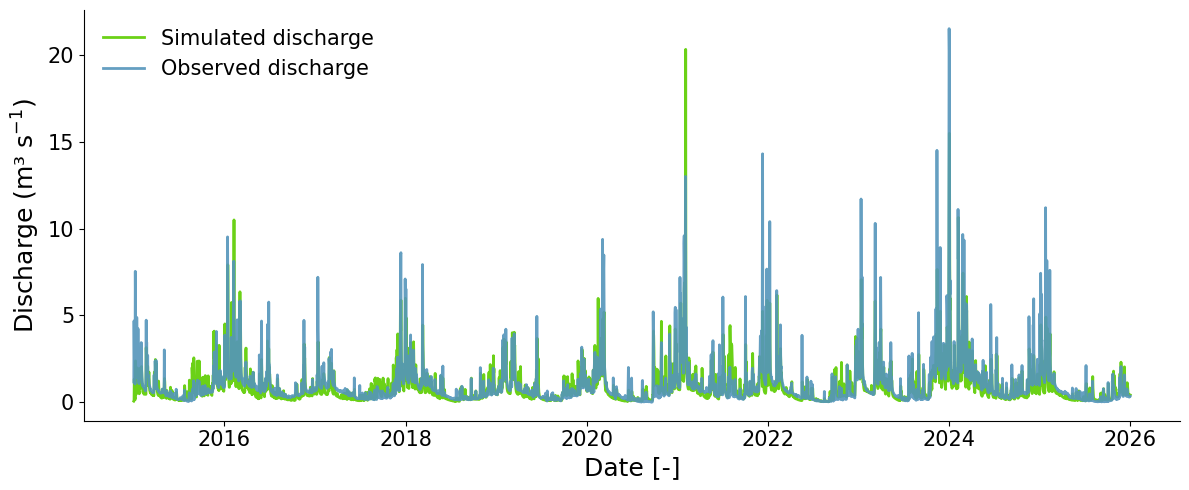

Correlation: 0.743
Bias: -0.112 m³/s


In [3]:
# --- make plot of the simulations and compute certain metrics ---
date_ini=pd.Timestamp("2015-01-01")
date_end=df_forcings.index.max()

# Simulate the model using the calibrated parameters
df_sim=runModelTimePeriod(
    df_forcings=df_forcings,
    parameters=params_calib_NSE, 
    states=States(), 
    date_ini=date_ini, 
    date_end=date_end
    )

# plot the simulated and observed discharge
fig,ax=plt.subplots(figsize=(12, 5))
ax.plot(
    df_sim.index,
    df_sim["Qsim"],
    color="#6BD117",
    lw=2,
    alpha=1,
    label="Simulated discharge"
)

ax.plot(
    df_sim.index,
    df_sim["Qobs"],
    color="#5495BB",
    lw=2,
    alpha=0.9,
    label="Observed discharge"
)

ax.legend(
    loc="upper left",
    fontsize=15,
    frameon=False
)
ax.spines["top"].set_visible(False)
ax.set_ylabel("Discharge (m³ s$^{-1}$)", fontsize=18)
ax.set_xlabel("Date [-]", fontsize=18)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=15)
fig.tight_layout()

plt.show()

# Compute certain metrics
mask=np.isfinite(df_sim["Qsim"]) & np.isfinite(df_sim["Qobs"])
df_sim = df_sim[mask]
corr=df_sim["Qsim"].corr(df_sim["Qobs"])
bias=np.mean(df_sim["Qsim"]-df_sim["Qobs"])
print(f"Correlation: {corr:.3f}")
print(f"Bias: {bias:.3f} m³/s")

Question 2:

In [4]:
# --- create a Perturbations object to generate perturbed forcings ---
model=RainfallRunoffModel(
    catchment_area=CATCHMENT_AREA_ZWALM,
    states=States(),
    parameters=params_calib_NSE
)

perturbations=Perturbations(
    df_forcings=df_forcings,
    sigma_P=0.5,
    sigma_ET=0.25,
    model=model,
    n_perturbations=30,
    date_ini=date_ini,
    date_end=date_end,
    n_warmup_days=100
)

# --- perturb and get the variance of the 10th ensemble for P ---
perturbed_forcings=perturbations.GeneratePerturbedForcings()

var=perturbed_forcings[[c for c in perturbed_forcings.columns 
                        if "precip" in c and "10" in c]].std().item()**2

print(f"Variance of the 10th ensemble for precipitation: {var:.3f} mm²")

Variance of the 10th ensemble for precipitation: 28.054 mm²


Question 3:

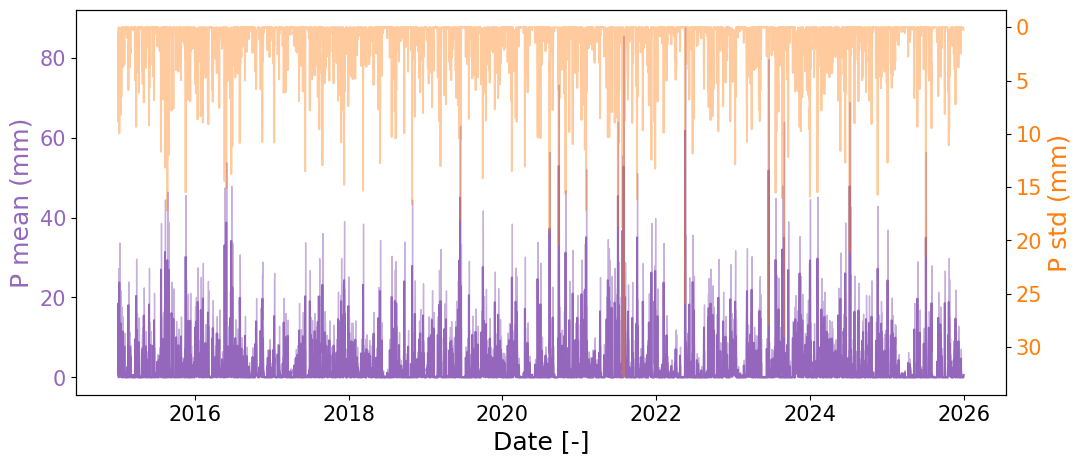

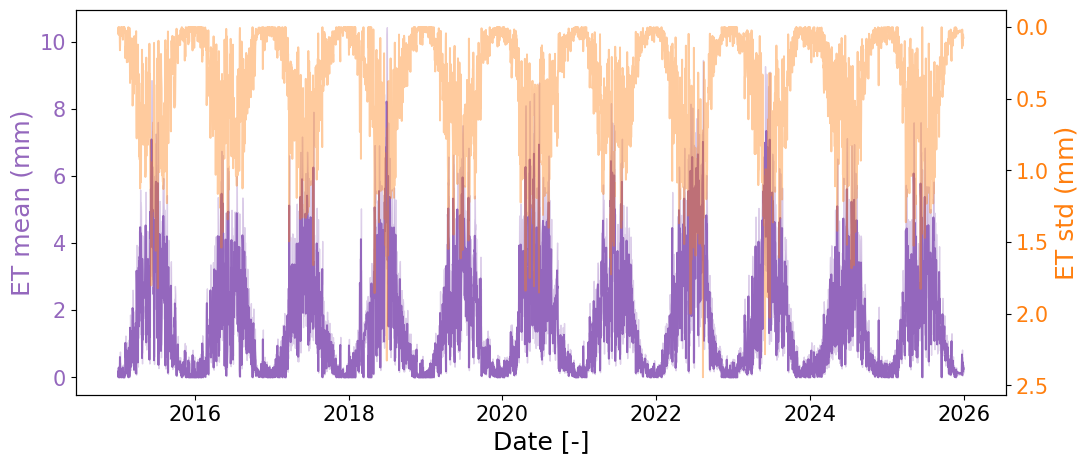

In [5]:
# --- generate the plots of the perturbed forcings ---
perturbations.PlotPerturbedForcings()

<div style="
    width: 100%;
    box-sizing: border-box;
    border: 1px solid #2979ff;
    border-left-width: 5px;
    background-color: #eef5ff;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 4px;
">
<strong>Assignment 2</strong><br>

Use the created `perturbations` object to make an open-loop simulation for the validation period. Use 100 warm-up days and answer the following questions:

1. Make a figure of the minimum, mean and maximum discharge for the time period 2019-01-01 2020-12-31. Plot the observed discharges as well. Use `ax.fillbetween(date, Qmin, Qmax, alpha=0.5, color="tab:blue")` to plot the difference between the maximal and minimal simulated discharges as an uncertainty band. 

2. When do you observe the highest model spread? And when is the model spread narrow? Answer in max 2 sentences.

3. Make a similar figure as for the discharge, but now for the state variable $S$. Instead of plotting the uncertainty as the difference between the minimum and maximum observed discharge, plot it as $\mu_{S(t)} \pm \sigma_{S(t)}$.
</div>

<div class="alert alert-block alert-info"> <b>Tip!!</b> 

You can use the `.open_loop()` functionality of the `Perturbations` class to perform the open loop. The results are stored in the class attribute `open_loop_results`, which you can acces after running the open loop.

</div>

In [6]:
# --- let the model do the open loop ---
perturbations.open_loop()
results = perturbations.open_loop_results

Question 1:

Text(0.5, 0, 'Date [-]')

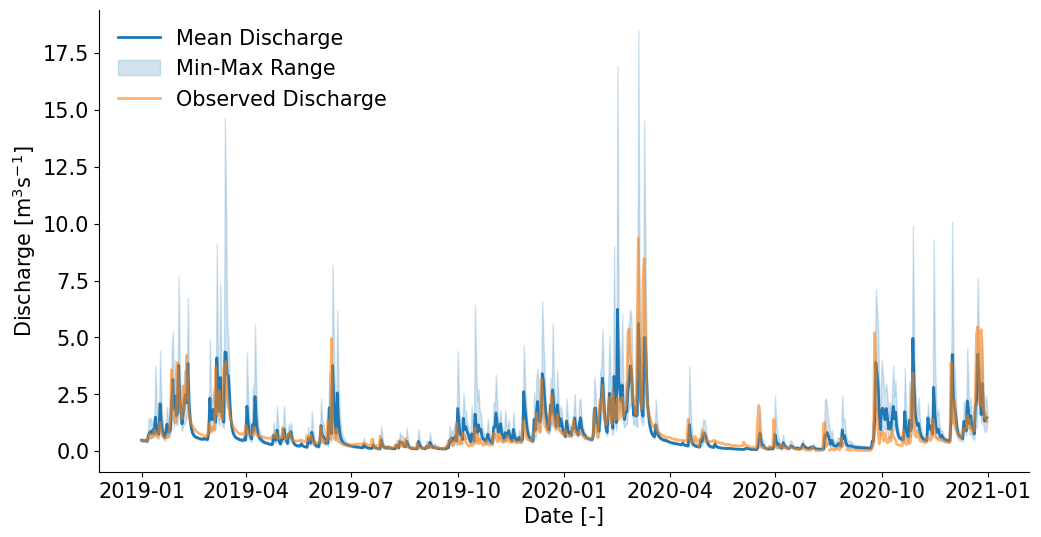

In [20]:
# --- plot the mean discharge and plot the min and maximum of the ensemble for the time period 2019-01-01 2021-12-31 ---
date_ini = pd.Timestamp("2019-01-01")
date_end = pd.Timestamp("2020-12-31")

df_plot = results.loc[(results.index >= date_ini) & (results.index <= date_end)]
fig,ax=plt.subplots(figsize=(12,6))
# plot the mean discharge
ax.plot(df_plot.index, df_plot["Qmean"], color='tab:blue', label='Mean Discharge', lw=2)
# plot the min and max of the ensemble
ax.fill_between(df_plot.index, df_plot["Qmin"], df_plot["Qmax"], color='tab:blue', alpha=0.2, label='Min-Max Range')
# plot the observed discharge
ax.plot(df_plot.index, df_plot["Qobs"], color='tab:orange', label='Observed Discharge', lw=2, alpha=0.6)
ax.legend(loc="upper left", fontsize=15, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylabel("Discharge [m$^3$s$^{-1}$]", fontsize=15)
ax.set_xlabel("Date [-]", fontsize=15)


Question 2:

The highest spread is found when the simulated dischrage is high, whereas the spread is low for low discharges. This can be related to the perturbation on the forcings, which is multiplicative and thus scales with the forcing values.

Text(0.5, 0, 'Date [-]')

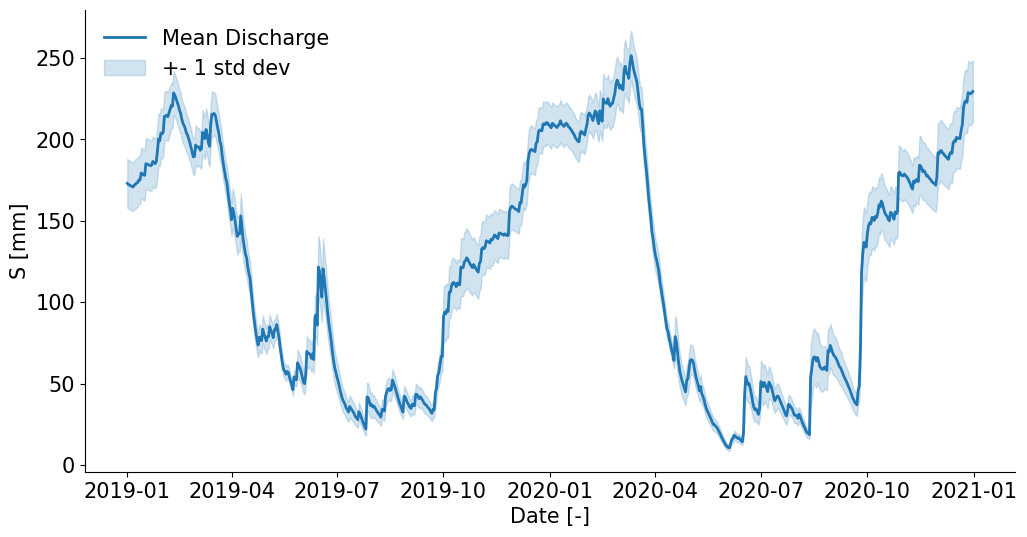

In [8]:
# --- plot the soil moisture reservoir and associated uncertainty (+- 1 std dev) ---
fig,ax=plt.subplots(figsize=(12,6))
# plot the mean discharge
ax.plot(df_plot.index, df_plot["Smean"], color='tab:blue', label='Mean Discharge', lw=2)
# plot the min and max of the ensemble
ax.fill_between(df_plot.index, df_plot["Smean"] - df_plot["Sstd"], df_plot["Smean"] + df_plot["Sstd"], color='tab:blue', alpha=0.2, label='+- 1 std dev')
ax.legend(loc="upper left", fontsize=15, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylabel("S [mm]", fontsize=15)
ax.set_xlabel("Date [-]", fontsize=15)

# check if there is a persistent bias between S1 soil moisture and the one from the model

In [9]:
soil_moisture=Path(r"C:\Users\lucboeyk\OneDrive - UGent\Doctoraat\Teaching\Hydrologische_processen_KUL\2026_2027\Practica_Python\Data\processed\data_zwalm\satellite_soil_moisture.csv")
df_sm=pd.read_csv(soil_moisture, index_col=0, parse_dates=True)

df_sm_plot=df_sm.loc[(df_sm.index >= date_ini) & (df_sm.index <= date_end)]


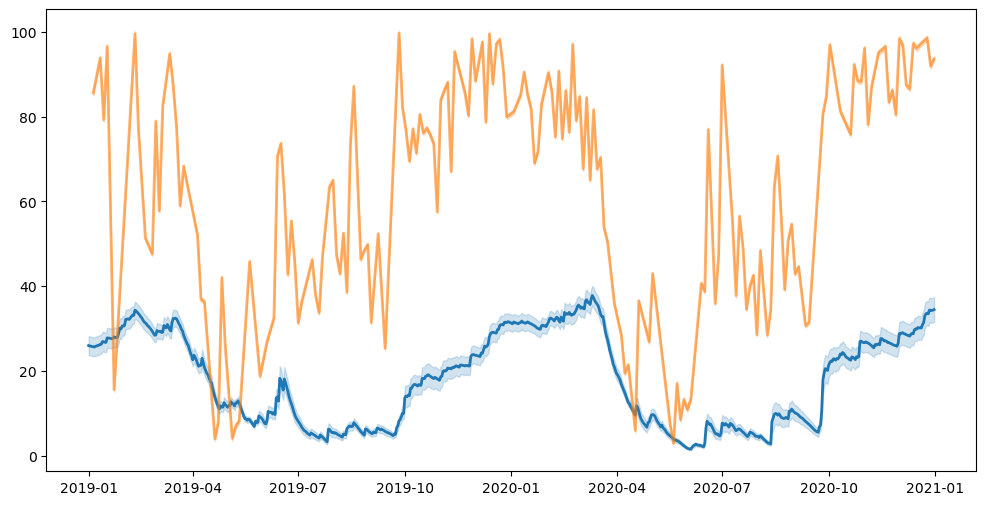

In [21]:
# --- plot the soil moisture reservoir and associated uncertainty (+- 1 std dev) ---
fig,ax=plt.subplots(figsize=(12,6))

df_plot[[c for c in df_plot.columns if c.startswith("S")]]=(df_plot[[c for c in df_plot.columns if c.startswith("S")]]/params_calib_NSE.S_max)*100


# plot the mean discharge
ax.plot(df_plot.index, df_plot["Smean"], color='tab:blue', label='Mean Discharge', lw=2)
# plot the min and max of the ensemble
ax.fill_between(df_plot.index, df_plot["Smean"] - df_plot["Sstd"], df_plot["Smean"] + df_plot["Sstd"], color='tab:blue', alpha=0.2, label='+- 1 std dev')

#plot the observed soil moisture


ax.plot(df_sm_plot.index, df_sm_plot["ssm"], color='tab:orange', label='Observed Soil Moisture', lw=2, alpha=0.6)
ax.fill_between(df_sm_plot.index, df_sm_plot["ssm"] - df_sm_plot["noise"], df_sm_plot["ssm"] + df_sm_plot["noise"], 
                color='tab:orange', 
                alpha=0.2, label='Observed Soil Moisture +- 1 std dev')

# ax.legend(loc="upper left", fontsize=15, frameon=False)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.tick_params(axis='both', which='major', labelsize=15)
# ax.set_ylabel("S [mm]", fontsize=15)
# ax.set_xlabel("Date [-]", fontsize=15)